(transformers)=
# Transformer predictive coding networks

This notebook builds the **smallest possible GPT-style Transformer** in
JAX/[Equinox](https://docs.kidger.site/equinox/) and trains it twice with ordinary backpropagation and with PyHGF using the hybrid approach described [here](deep_networks_implementation).

The two learners are then put **side by side** and both generate text. The pipeline is deliberately minimal and self-contained: a **char-level
tokenizer**, a tiny **GPT** (2 layers, 64-dim, 4 heads), short training loops, and autoregressive text generation.

The PyHGF machinery assembles a **mixed pipeline**: a sequence of parts where each slot holds either a *frozen calculation* (normalisation, the attention mixing, things with nothing to learn, which only translate errors with hand-derived formulas) or a *learning PyHGF network*. Walked forward, the pipeline predicts. Walked backward, each part learns locally and hands the error at its input to the part behind it.

In [2]:
import time

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
import seaborn as sns
from jax import random

from pyhgf.model import (
    DeepNetworkAdapter,
    FusedPipeline,
    from_embedding,
    from_feedforward,
    from_linear,
    hybrid_from_gpt,
)

plt.rcParams["figure.constrained_layout.use"] = True

/Users/au646069/git/pyhgf/pyhgf/__init__.py:124: RuntimeWarning: pyhgf sets --xla_cpu_use_thunk_runtime=false to avoid a large slowdown in gradients through the belief propagation scan on jaxlib 0.6.2. jax was already imported, so the flag may arrive too late to take effect. Import pyhgf before jax, or set XLA_FLAGS yourself, to be sure of it.
  LEGACY_CPU_RUNTIME_FLAG = _use_legacy_cpu_runtime()


## Data and tokenizer

We use a **character-level tokenizer**: the vocabulary is simply the set of unique characters in the corpus. `stoi`/`itos` map characters to integer ids and back. This needs no external library and keeps the vocabulary tiny (a few dozen tokens), which is ideal for a minimal model.

The corpus is a short thematic text repeated a few times so the tiny model has enough sequence windows to learn a reproducible pattern.

In [3]:
corpus = (
    "predictive coding networks learn by minimizing prediction errors. "
    "each layer predicts the activity of the next, and updates its weights locally. "
) * 30

chars = sorted(set(corpus))
stoi = {c: i for i, c in enumerate(chars)}
itos = {i: c for c, i in stoi.items()}
vocab_size = len(chars)

encode = lambda s: jnp.array([stoi[c] for c in s], dtype=jnp.int32)
decode = lambda ids: "".join(itos[int(i)] for i in ids)

data = encode(corpus)
print(
    f"vocab_size = {vocab_size}, corpus length = {len(data)} tokens, vocabulary: {''.join(chars)!r}"
)

vocab_size = 27, corpus length = 4350 tokens, vocabulary: ' ,.abcdefghiklmnoprstuvwxyz'


### Batching

Training examples are random windows of length `T` (the context length). For a window starting at `i`, the input is `data[i:i+T]` and the target is the same window shifted by one (`data[i+1:i+T+1]`),  i.e. *predict the next token at every position*.

In [4]:
T = 32  # context length


def get_batch(key, batch_size):
    """Draw ``batch_size`` windows of ``T`` characters and their next characters."""
    ix = random.randint(key, (batch_size,), 0, len(data) - T - 1)
    windows = ix[:, None] + jnp.arange(T)  # one gather, no Python loop
    return data[windows], data[windows + 1]


xb, yb = get_batch(random.key(0), batch_size=4)
print("x:", xb.shape, "y:", yb.shape)
print("example input :", decode(xb[0]))
print("example target:", decode(yb[0]))

x: (4, 32) y: (4, 32)
example input : orks learn by minimizing predict
example target: rks learn by minimizing predicti


## The architecture

A GPT is a **feedforward** stack (no recurrence): token+position embeddings, then `L` identical blocks, then a final norm and an unembedding head. Each block is two sub-layers, each wrapped in **pre-norm + residual**:

```
x  ->  x + Attention(LayerNorm(x))   # mixes information ACROSS positions
x  ->  x + FeedForward(LayerNorm(x)) # acts on each position INDEPENDENTLY
```

Following the Equinox convention, every module operates on a **single sequence** `x` of shape `(T, D)`; we `jax.vmap` over the batch only at the loss. Per-token linear layers are applied with `jax.vmap` over the `T` axis.

### Multi-head causal self-attention

The only operation that moves information *between token positions*. The `W_{Q,K,V,O}` are learnable; the mixing matrix `softmax(QKᵀ/√d)` is computed from the data (no weights). The causal mask forbids attending to future positions.

In [5]:
class MultiHeadAttention(eqx.Module):
    """Causal multi-head self-attention over one sequence of shape ``(T, D)``."""

    wqkv: eqx.nn.Linear
    wo: eqx.nn.Linear
    n_heads: int = eqx.field(static=True)
    head_dim: int = eqx.field(static=True)

    def __init__(self, dim, n_heads, key):
        k1, k2 = random.split(key)
        # The query, key, and value projections read the same input, so they
        # are one fused matrix: the output stacks the three streams on the
        # feature axis, [q | k | v], computed as a single matrix product.
        self.wqkv = eqx.nn.Linear(dim, 3 * dim, use_bias=False, key=k1)
        self.wo = eqx.nn.Linear(dim, dim, use_bias=False, key=k2)
        self.n_heads = n_heads
        self.head_dim = dim // n_heads

    def __call__(self, x):
        """Mix information across the positions of ``x`` of shape ``(T, D)``."""
        seq_len, dim = x.shape
        q, k, v = jnp.split(jax.vmap(self.wqkv)(x), 3, axis=-1)
        # (T, D) -> (n_heads, T, head_dim)
        split = lambda a: a.reshape(seq_len, self.n_heads, self.head_dim).transpose(
            1, 0, 2
        )
        q, k, v = split(q), split(k), split(v)
        scores = q @ k.transpose(0, 2, 1) / jnp.sqrt(self.head_dim)  # (H, T, T)
        mask = jnp.tril(jnp.ones((seq_len, seq_len)))
        scores = jnp.where(mask[None] == 0, -jnp.inf, scores)
        attn = jax.nn.softmax(scores, axis=-1)
        out = (attn @ v).transpose(1, 0, 2).reshape(seq_len, dim)  # back to (T, D)
        return jax.vmap(self.wo)(out)

### Feed-forward (per-position MLP)

`Linear(D -> 4D) -> GELU -> Linear(4D -> D)`, applied identically and independently to every position.

In [6]:
class FeedForward(eqx.Module):
    """Per-position MLP: ``Linear(dim, hidden)``, GELU, ``Linear(hidden, dim)``."""

    fc1: eqx.nn.Linear
    fc2: eqx.nn.Linear

    def __init__(self, dim, hidden, key):
        k1, k2 = random.split(key)
        self.fc1 = eqx.nn.Linear(dim, hidden, key=k1)
        self.fc2 = eqx.nn.Linear(hidden, dim, key=k2)

    def __call__(self, x):
        """Apply the MLP to every position of ``x`` of shape ``(T, D)``."""
        return jax.vmap(self.fc2)(jax.nn.gelu(jax.vmap(self.fc1)(x)))

### Transformer block and full GPT

Pre-norm + residual around each sub-layer, then stack `L` blocks between the embeddings and the unembedding head.

In [7]:
class Block(eqx.Module):
    """One Transformer block: pre-norm attention and feed-forward sub-layers."""

    attn: MultiHeadAttention
    ff: FeedForward
    n1: eqx.nn.LayerNorm
    n2: eqx.nn.LayerNorm

    def __init__(self, dim, n_heads, hidden, key):
        k1, k2 = random.split(key)
        self.attn = MultiHeadAttention(dim, n_heads, k1)
        self.ff = FeedForward(dim, hidden, k2)
        self.n1 = eqx.nn.LayerNorm(dim)
        self.n2 = eqx.nn.LayerNorm(dim)

    def __call__(self, x):
        """Run both sub-layers on ``x`` of shape ``(T, D)`` through their residuals."""
        x = x + self.attn(jax.vmap(self.n1)(x))
        x = x + self.ff(jax.vmap(self.n2)(x))
        return x


class GPT(eqx.Module):
    """Decoder-only Transformer mapping token ids to logits over the vocabulary."""

    tok_emb: eqx.nn.Embedding
    pos_emb: eqx.nn.Embedding
    blocks: list
    norm_f: eqx.nn.LayerNorm
    head: eqx.nn.Linear
    context_length: int = eqx.field(static=True)

    def __init__(self, vocab_size, dim, n_heads, hidden, n_layers, context_length, key):
        keys = random.split(key, n_layers + 3)
        self.tok_emb = eqx.nn.Embedding(vocab_size, dim, key=keys[0])
        self.pos_emb = eqx.nn.Embedding(context_length, dim, key=keys[1])
        self.blocks = [
            Block(dim, n_heads, hidden, keys[2 + i]) for i in range(n_layers)
        ]
        self.norm_f = eqx.nn.LayerNorm(dim)
        self.head = eqx.nn.Linear(dim, vocab_size, use_bias=False, key=keys[-1])
        self.context_length = context_length

    def __call__(self, idx):
        """Map token ids ``(T,)`` to logits of shape ``(T, vocab_size)``."""
        seq_len = idx.shape[0]
        x = jax.vmap(self.tok_emb)(idx) + jax.vmap(self.pos_emb)(jnp.arange(seq_len))
        for block in self.blocks:
            x = block(x)
        return jax.vmap(self.head)(jax.vmap(self.norm_f)(x))

In [8]:
DIM, HEADS, HIDDEN, LAYERS, BATCH = 64, 4, 128, 2, 16

reference = GPT(vocab_size, DIM, HEADS, HIDDEN, LAYERS, T, key=random.key(0))

n_params = sum(
    x.size for x in jax.tree_util.tree_leaves(eqx.filter(reference, eqx.is_array))
)
print(f"number of parameters: {n_params:,}")

# sanity check: forward pass shape
logits = reference(data[:T])
print("logits shape:", logits.shape, "(T, vocab_size)")

number of parameters: 72,064
logits shape: (32, 27) (T, vocab_size)


## Training with backpropagation

Next-token prediction with cross-entropy loss and Adam. `eqx.filter_value_and_grad` differentiates only the array leaves (the weights), leaving the static config untouched. This `loss.backward()`-style global gradient (one backward sweep threading information from the loss through every layer) is precisely what the PyHGF port replaces with a local, layer-wise prediction-error rule.

In [9]:
def ce_loss(model, x, y):
    """Mean cross-entropy of the model on a batch ``x`` with targets ``y``."""
    logits = jax.vmap(model)(x)  # (B, T, vocab_size)
    return optax.softmax_cross_entropy_with_integer_labels(logits, y).mean()


optimiser = optax.adam(3e-3)
opt_state = optimiser.init(eqx.filter(reference, eqx.is_array))


@eqx.filter_jit
def backprop_step(model, opt_state, x, y):
    """Take one Adam step and return the updated model, optimiser state and loss."""
    loss, grads = eqx.filter_value_and_grad(ce_loss)(model, x, y)
    updates, opt_state = optimiser.update(grads, opt_state)
    return eqx.apply_updates(model, updates), opt_state, loss


N_STEPS = 400

key = random.key(1)
reference_losses = []
t0 = time.perf_counter()
for it in range(N_STEPS):
    key, bk = random.split(key)
    x, y = get_batch(bk, BATCH)
    reference, opt_state, loss = backprop_step(reference, opt_state, x, y)
    reference_losses.append(float(loss))
    if it % 100 == 0 or it == N_STEPS - 1:
        print(f"step {it:4d}  |  loss {float(loss):.4f}")
backprop_seconds = time.perf_counter() - t0
print(f"backpropagation: {N_STEPS} steps in {backprop_seconds:.0f} s")

step    0  |  loss 3.4361
step  100  |  loss 0.3172
step  200  |  loss 0.1258
step  300  |  loss 0.0915
step  399  |  loss 0.0804
backpropagation: 400 steps in 3 s


## The same Transformer, learning through PyHGF

Now every weight in the model learns through PyHGF: the four attention
tables of each block, the feed-forwards, both embedding tables, and the output
head. Only the weightless calculations stay frozen: normalisations, the
attention mixing, and the shortcut junctions, which translate errors with
hand-derived formulas.

### The pinned-confidence configuration

Every learning part keeps the same **pinned-confidence configuration**:
volatility levels frozen and high prior confidence (precision, a belief's
inverse variance) on the hidden and input layers, so their beliefs barely move
during the update sweep (a *silent interior*; see the
[theory page](./0.5-Deep_networks_theory.ipynb)), with unit precision on the
observed output layer.

### The learning rule

The weights learn here in the exact **backprop-parity** mode
(`learning_kind="precision_weighted"`, the adapter's default): the hidden
layer's belief shift is its routed error *divided by* its posterior
confidence, and the confidence-weighted update multiplies that same
confidence back in. The two cancel exactly, so each local update coincides
with the backpropagated gradient (the correspondence is derived in the
[theory page](./0.5-Deep_networks_theory.ipynb)). This makes the comparison with
the baseline as direct as possible: the two learners apply the same weight
updates and differ only in how they reach them, local message passing
against a global backward sweep.

### The categorical head

The head is a **categorical belief layer**: its nodes jointly represent
one softmax choice over the characters, so the model optimises exactly the
same cross-entropy objective as the baseline. Training clamps the truth
"the next character is this one", a one-hot pattern, directly onto those
beliefs, and the classification error arises from PyHGF's own
prediction-error rule.
The head's own update is the plain cross-entropy gradient (the `one_hot − softmax` 
error times the activity), exactly the backprop head's. The head's forward output is
already a probability distribution over the characters.

In [10]:
PARITY = dict(
    volatility_parent=False,
    precision=1e4,
    expected_precision=1e4,
)
PARITY_LEAF = dict(volatility_parent=False)

scratch = GPT(vocab_size, DIM, HEADS, HIDDEN, LAYERS, T, key=random.key(0))


def pyhgf_part(net):
    """Wrap a deep network as a pipeline part that learns through PyHGF."""
    # "precision_weighted" is the exact backprop-parity mode: each local update
    # coincides with the backpropagated gradient.
    return DeepNetworkAdapter(
        net, optimiser=optax.adam(3e-3), learning_kind="precision_weighted"
    )


pc_gpt = hybrid_from_gpt(
    scratch,
    attention_parts=[
        {
            name: pyhgf_part(
                from_linear(
                    getattr(b.attn, name), leaf_kwargs=PARITY_LEAF, layer_kwargs=PARITY
                )
            )
            for name in ("wqkv", "wo")
        }
        for b in scratch.blocks
    ],
    ff_parts=[
        pyhgf_part(
            from_feedforward(
                b.ff.fc1, b.ff.fc2, leaf_kwargs=PARITY_LEAF, layer_kwargs=PARITY
            )
        )
        for b in scratch.blocks
    ],
    head_part=pyhgf_part(
        from_linear(
            scratch.head,
            leaf_kwargs=dict(kind="categorical", **PARITY_LEAF),
            layer_kwargs=PARITY,
        )
    ),
    token_part=pyhgf_part(
        from_embedding(scratch.tok_emb, leaf_kwargs=PARITY_LEAF, layer_kwargs=PARITY)
    ),
    position_part=pyhgf_part(
        from_embedding(scratch.pos_emb, leaf_kwargs=PARITY_LEAF, layer_kwargs=PARITY)
    ),
)

pc_pipeline = FusedPipeline(
    pc_gpt,
    # The cross-entropy error at the head, formed inside the compiled step:
    # feeding probs - one_hot through the correct-and-clamp entry clamps
    # exactly the one-hot truth on the beliefs.
    error_fn=lambda probs, y: probs - jax.nn.one_hot(y, vocab_size),
)

# The timed loop does the same work as the backpropagation loop (draw a
# batch, take one step) and only stores each step's output; every metric
# is computed after the fact, below.
all_probs, all_targets = [], []
key = random.key(4)
t0 = time.perf_counter()
for it in range(N_STEPS):
    key, bk = random.split(key)
    x, y = get_batch(bk, BATCH)
    probs, _ = pc_pipeline.step(x, y)  # (B, T, vocab): one softmax per position
    all_probs.append(probs)
    all_targets.append(y)
probs.block_until_ready()  # flush the queued steps before stopping the clock
pyhgf_seconds = time.perf_counter() - t0
print(f"PyHGF: {N_STEPS} steps in {pyhgf_seconds:.0f} s")

# Metrics, after the fact. The head's output is a probability distribution,
# so its cross-entropy is directly comparable with the reference's.
all_probs, all_targets = jnp.stack(all_probs), jnp.stack(all_targets)
p_target = jnp.take_along_axis(all_probs, all_targets[..., None], axis=-1)
pc_losses = -jnp.log(jnp.clip(p_target, 1e-9, None)).mean(axis=(1, 2, 3))
accuracies = (all_probs.argmax(-1) == all_targets).mean(axis=(1, 2))
for it in (0, 100, 200, 300, N_STEPS - 1):
    print(f"step {it:4d}  |  next-character accuracy {float(accuracies[it]):.2f}")

PyHGF: 400 steps in 3 s
step    0  |  next-character accuracy 0.06
step  100  |  next-character accuracy 0.91
step  200  |  next-character accuracy 0.96
step  300  |  next-character accuracy 0.98
step  399  |  next-character accuracy 0.97


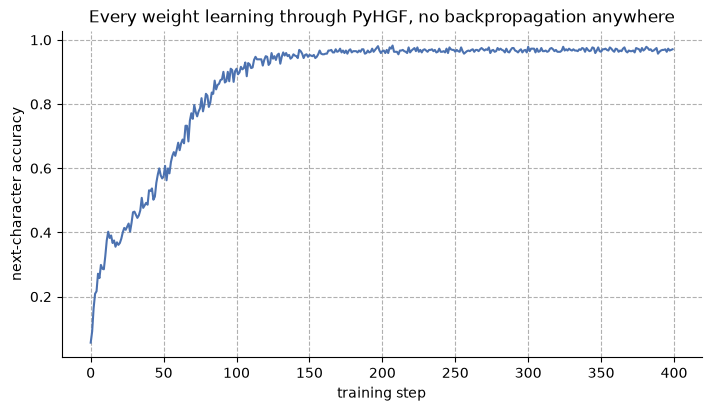

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(accuracies, color="#4c72b0", linewidth=1.5)
ax.set(
    xlabel="training step",
    ylabel="next-character accuracy",
    title="Every weight learning through PyHGF, no backpropagation anywhere",
)
ax.grid(linestyle="--")
sns.despine()

## Accuracy and execution time

Both models are trained for the same number of steps on batches drawn in the same
way, and both run as one compiled program per step, so their training
curves and wall-clock times can be put side by side. With the categorical
head, both learners optimise the *same* softmax cross-entropy, so the
curves are directly comparable — and in the backprop-parity mode used here
each local update coincides with the backpropagated gradient.

time per step: backprop 8.3 ms, PyHGF 8.1 ms (1.0x)


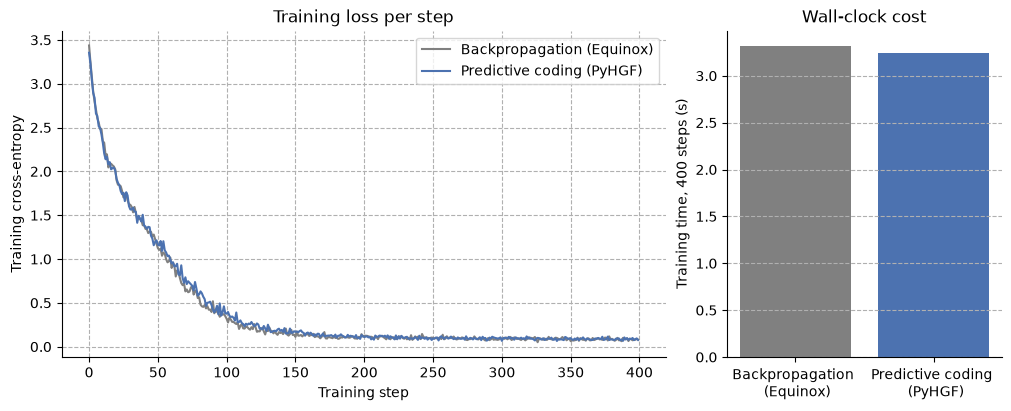

In [13]:
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(10, 4), gridspec_kw={"width_ratios": [2.2, 1]}
)

ax1.plot(
    reference_losses, label="Backpropagation (Equinox)", color="grey", linewidth=1.5
)
ax1.plot(pc_losses, label="Predictive coding (PyHGF)", color="#4c72b0", linewidth=1.5)
ax1.set(
    xlabel="Training step",
    ylabel="Training cross-entropy",
    title="Training loss per step",
)
ax1.grid(linestyle="--")
ax1.legend()

bars = ax2.bar(
    ["Backpropagation \n (Equinox)", "Predictive coding \n (PyHGF)"],
    [backprop_seconds, pyhgf_seconds],
    color=["grey", "#4c72b0"],
)

ax2.set(ylabel=f"Training time, {N_STEPS} steps (s)", title="Wall-clock cost")
ax2.grid(axis="y", linestyle="--")

sns.despine()

ms_backprop = backprop_seconds / N_STEPS * 1e3
ms_pyhgf = pyhgf_seconds / N_STEPS * 1e3
print(
    f"time per step: backprop {ms_backprop:.1f} ms, "
    f"PyHGF {ms_pyhgf:.1f} ms ({ms_pyhgf / ms_backprop:.1f}x)"
)

In terms of *learning per step*, the two are close: both collapse the loss
within the first few hundred steps and flatten near the same floor. In
terms of *wall-clock*, the predictive-coding learner stays within a small
factor of backpropagation.

## Generating text

Autoregressive generation is an **inference-time loop** around the
feedforward model: feed the current context (cropped to the context length),
take the prediction at the last position, sample the next token, append, and
repeat. This outer loop is *not* recurrence in the architecture; the model
itself remains feedforward. Both learners generate the same way; the only
difference is where the next-character distribution comes from. The backprop
model outputs logits:

In [14]:
def generate_backprop(model, idx, n_new, key):
    """Sample ``n_new`` characters from the backpropagation-trained model."""
    for _ in range(n_new):
        logits = model(idx[-model.context_length :])[-1]  # last-position logits
        key, sub = random.split(key)
        next_id = random.categorical(sub, logits).astype(jnp.int32)
        idx = jnp.concatenate([idx, next_id[None]])
    return idx


out = generate_backprop(reference, encode("predictive"), n_new=120, key=random.key(2))
print(decode(out))

predictive coding networks learn by minimizing prediction errors. each layer predicts the activity of the next, and updates its we


The PyHGF model's forward pass already ends in a probability distribution
over the characters (its categorical head), which is sampled from directly:

In [15]:
def generate_pyhgf(pipeline, idx, n_new, key):
    """Sample ``n_new`` characters from the categorical head of the pipeline."""
    for _ in range(n_new):
        window = idx[-T:]
        probs = pipeline.predict(window[None])[0]  # forward pass only
        p = probs[window.shape[0] - 1]
        key, sub = random.split(key)
        next_id = random.categorical(sub, jnp.log(p)).astype(jnp.int32)
        idx = jnp.concatenate([idx, next_id[None]])
    return idx


out = generate_pyhgf(pc_pipeline, encode("predictive"), n_new=120, key=random.key(5))
print(decode(out))

predictive coding networks learn by minimizing prediction errors. each layer predicts the activity of the next, and updates its we


# System configuration

In [16]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pyhgf,jax,jaxlib

Last updated: Tue, 01 Sep 2026

Python implementation: CPython
Python version       : 3.12.13
IPython version      : 9.16.1

pyhgf : 0.3.0
jax   : 0.6.2
jaxlib: 0.6.2

equinox   : 0.13.8
jax       : 0.6.2
matplotlib: 3.11.1
optax     : 0.2.8
platform  : 1.0.8
pyhgf     : 0.3.0
seaborn   : 0.13.2

Watermark: 2.6.0

